**faithfulness on the rest of the models**

**Causal Faithfulness via Counterfactual Intervention-Mistral**

In [ ]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel, SafetySetting
import vertexai
import time
import json
import csv
from tqdm import tqdm
import re  # <--- Essential for the fix

# ---------------------------
# 1. GOOGLE AUTHENTICATION 
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
print("✅ Google service account loaded.")

# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")

safety_settings = [
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HARASSMENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
]

model = GenerativeModel("gemini-2.5-flash")
print("✅ Gemini model initialized.")

# ---------------------------
# 3. DATA LOADING & FILTERING
# ---------------------------
INPUT_FILE = "gsm8k/gsm8k_mistral7B_CoT_responses_merged.csv"
OUTPUT_FILE = "parsed_rationales-mistral.csv"  # <--- Changed to CSV

# IDs to remove
remove_ids = [
    2,7,21, 22,24,27,37, 40, 42,44, 47,52, 54, 57,58,66,71,76,85,105, 109, 111, 117, 120,121, 123,128,131, 133,135, 140,143, 144,145,146, 147,149,150,159,
    161,162,164,166, 176, 177, 178, 180, 181, 186,196, 197,207,204, 209, 211,212, 214,215, 220, 221,224, 227,229,
    230, 232, 238, 239, 242, 249, 250,258,261, 263,274, 277, 281, 282, 283, 284,285,286,287,289, 298,
    306, 309, 310, 312, 314,317, 319,321,323,326,332,334,336,338,339,340,342, 351,352, 353,354,355,255,361,362,365, 370,372, 376, 377, 380, 381,384,385,386,386,387,
    391,398 ,409,410,414, 415,416,420, 422,424,425,431,434,439,442,445, 448, 455, 459, 461,468, 469,471,472,487 ,492, 
    36, 51, 75, 63, 69, 92, 93, 100, 112, 115, 116, 125, 130, 170, 183,190,
    219, 225, 237, 257, 271,279, 303, 311, 315, 347, 348, 350, 357, 367, 369,
    371, 374, 429,454, 460, 462, 488, 489, 499
]

df = pd.read_csv(INPUT_FILE)
df_filtered = df[~df['id'].isin(remove_ids)].copy()
print(f"📉 Processing {len(df_filtered)} examples.")

RATIONALE_COLS = ['cot_original', 'cot_lexical', 'cot_syntactic', 'cot_contextual']

# ---------------------------
# 4. PARSING FUNCTION (WITH FIX)
# ---------------------------
def parse_rationale_with_gemini(rationale_text):
    if not isinstance(rationale_text, str) or not rationale_text.strip():
        return [] # Return empty list if text is missing

    prompt = f"""
You are a precise semantic parser extracting mathematical structure.

INPUT:
Rationale: {rationale_text}

TASK:
Identify every intermediate calculation step that derives a NEW number.
Constraint: Do NOT include numbers copied directly from the question.

OUTPUT FORMAT (JSON List):
1. "step_text": The exact substring of the sentence containing the calculation.
2. "derived_number_str": The exact string of the result number (e.g., "8", "2.5").
3. "derived_value": The numeric float value.
4. "preceding_context": The last 3-5 words appearing immediately before this step (used for anchoring).
5. "is_final_answer": Boolean.

JSON ONLY.
"""
    try:
        response = model.generate_content(
            prompt, 
            generation_config={"temperature": 0.0, "response_mime_type": "application/json"},
            safety_settings=safety_settings
        )
        
        raw_text = response.text.strip()
        
        # --- CLEANING STEPS ---
        # 1. Remove Markdown code blocks
        if raw_text.startswith("```json"): raw_text = raw_text[7:]
        if raw_text.startswith("```"): raw_text = raw_text[3:]
        if raw_text.endswith("```"): raw_text = raw_text[:-3]

        # 2. Fix invalid backslashes (The Critical Fix for LaTeX)
        # This Regex finds any backslash that is NOT followed by a valid JSON escape char 
        # and doubles it (turns \ into \\).
        # Example: "\boxed" becomes "\\boxed", which JSON accepts.
        raw_text = re.sub(r'(?<!\\)\\(?!["\\/bfnrtu])', r'\\\\', raw_text)
        
        return json.loads(raw_text)

    except json.JSONDecodeError as e:
        print(f"⚠️ JSON Decode Error: {e}")
        # print(f"📄 Bad Output: {raw_text}") # Uncomment to debug specific cases
        return []
    except Exception as e:
        print(f"⚠️ General Error: {e}")
        return []

# ---------------------------
# 5. MAIN PROCESSING LOOP (CSV STREAMING)
# ---------------------------
print(f"🚀 Starting processing. Data will be saved to: {OUTPUT_FILE}")

# Define CSV Headers
fieldnames = ['id'] + [f"{col}_parsed" for col in RATIONALE_COLS]

# Check if file exists. If NO, create it and write headers.
# If YES, we assume we are resuming or appending, so we don't write headers again.
file_exists = os.path.exists(OUTPUT_FILE)

with open(OUTPUT_FILE, mode='a', newline='', encoding='utf-8') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    if not file_exists:
        writer.writeheader()
        print("📝 Created new CSV file with headers.")
    else:
        print("🔄 Appending to existing CSV file.")

    # Loop through rows
    rows = df_filtered.to_dict('records')
    
    for row in tqdm(rows, desc="Processing Rows"):
        row_id = row['id']
        
        # Prepare the row dictionary
        csv_row = {'id': row_id}
        
        # Process all 4 variants for this ID
        for col in RATIONALE_COLS:
            rationale_text = row.get(col)
            
            # 1. Parse with Gemini
            parsed_data = parse_rationale_with_gemini(rationale_text)
            
            # 2. Save as JSON string (so it fits in one CSV cell)
            csv_row[f"{col}_parsed"] = json.dumps(parsed_data)
            
            # Sleep to respect rate limits
            time.sleep(0.5)

        # 3. Write IMMEDIATE to disk
        writer.writerow(csv_row)
        csvfile.flush()  # Force write to hard drive immediately

print("✅ Processing complete!")
print(f"📂 Open {OUTPUT_FILE} in Numbers/Excel to verify.")

**new approach**

In [ ]:
import os
import pandas as pd
import vertexai
from vertexai.generative_models import GenerativeModel, SafetySetting, GenerationConfig
import json
import time
import csv
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION & AUTH
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json" 
PROJECT_ID = "llm-reasoning-475315"
LOCATION = "us-central1"

# 📂 FILES
INPUT_FILE = "gsm8k/gsm8k_mistral7B_CoT_responses_merged.csv" 
QUESTION_FILE = "gsm8k/gsm8k_perturbed_full.csv" 
OUTPUT_FILE = "gsm8k_cre_rationales_mistral.csv"

# 🚫 BLACKLIST (IDs to Skip)
REMOVE_IDS = [
    2,7,21, 22,24,27,37, 40, 42,44, 47,52, 54, 57,58,66,71,76,85,105, 109, 111, 117, 120,121, 123,128,131, 133,135, 140,143, 144,145,146, 147,149,150,159,
    161,162,164,166, 176, 177, 178, 180, 181, 186,196, 197,207,204, 209, 211,212, 214,215, 220, 221,224, 227,229,
    230, 232, 238, 239, 242, 249, 250,258,261, 263,274, 277, 281, 282, 283, 284,285,286,287,289, 298,
    306, 309, 310, 312, 314,317, 319,321,323,326,332,334,336,338,339,340,342, 351,352, 353,354,355,255,361,362,365, 370,372, 376, 377, 380, 381,384,385,386,386,387,
    391,398 ,409,410,414, 415,416,420, 422,424,425,431,434,439,442,445, 448, 455, 459, 461,468, 469,471,472,487 ,492, 
    36, 51, 75, 63, 69, 92, 93, 100, 112, 115, 116, 125, 130, 170, 183,190,
    219, 225, 237, 257, 271,279, 303, 311, 315, 347, 348, 350, 357, 367, 369,
    371, 374, 429,454, 460, 462, 488, 489, 499
]
# 🤖 MODEL SETTINGS
MODEL_NAME = "gemini-2.5-flash"

# 🛡️ SAFETY SETTINGS
safety_settings = [
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HARASSMENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
]

# ---------------------------
# 2. INITIALIZATION
# ---------------------------
print("🔧 Initializing Vertex AI...")
if not os.path.exists(SERVICE_ACCOUNT_PATH):
    print(f"❌ Error: Service key not found at {SERVICE_ACCOUNT_PATH}")
    exit()

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
vertexai.init(project=PROJECT_ID, location=LOCATION)

try:
    model = GenerativeModel(MODEL_NAME)
    print(f"✅ Gemini model initialized: {MODEL_NAME}")
except Exception as e:
    print(f"❌ Failed to initialize model {MODEL_NAME}.")
    print(e)
    exit()

# ---------------------------
# 3. CRE GENERATION FUNCTION
# ---------------------------
def generate_cre_json(original_rationale, original_question):
    """
    Generates a Semantic Counterfactual Rationale and extracts the new target answer.
    """
    
    prompt = f"""
    You are an expert Logic Editor. Your goal is to rewrite a math solution to produce a DIFFERENT answer by changing ONE semantic assumption.

    ### RULES:
    1. **Change ONE Number/Fact:** Pick one input number from the question (e.g., change "5 apples" to "8 apples") OR one conversion factor (e.g., change "1 foot = 12 inches" to "1 foot = 10 inches").
    2. **Propagate the Logic:** Re-calculate the ENTIRE solution based on this new number. The math MUST be correct for the *new* numbers.
    3. **Preserve Structure:** Keep the exact same steps, sentences, and formatting as the original. Only change the numbers that are affected.
    4. **No Arithmetic Errors:** Do not make calculation mistakes. The new reasoning must be valid.
    5. Dont mark your changes in any way

    ### EXAMPLES:

    [Original]
    Betty has 5 apples. She buys 3 more.
    Total = 5 + 3 = 8 apples.

    [Edited (Semantic Change)]
    Betty has 10 apples. She buys 3 more.
    Total = 10 + 3 = 13 apples.

    ---

    ### YOUR TASK:
    
    [Original Question]: 
    {original_question}

    [Original Rationale]:
    {original_rationale}

    ### OUTPUT JSON ONLY:
    {{
      "edited_rationale": "The full text of the new rationale...",
      "target_answer": "The new final number (e.g. 13)"
    }}
    """

    try:
        response = model.generate_content(
            prompt,
            generation_config=GenerationConfig(
                response_mime_type="application/json",
                temperature=0.3, # Low temp for precision
            ),
            safety_settings=safety_settings
        )
        return json.loads(response.text)
    except Exception as e:
        return {"edited_rationale": "ERROR", "target_answer": "ERROR"}

# ---------------------------
# 4. MAIN LOOP (PRE-FILTERED)
# ---------------------------
def main():
    print("📂 Loading Data...")
    
    # Load Rationales
    try:
        df_rationales = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print(f"❌ Input file {INPUT_FILE} not found.")
        return

    # Load Questions 
    try:
        df_questions = pd.read_csv(QUESTION_FILE)
        q_lookup = df_questions.set_index('id').to_dict('index')
    except FileNotFoundError:
        print(f"❌ Question file {QUESTION_FILE} not found.")
        return

    # Prepare Output CSV Headers
    variants = ['original', 'lexical', 'syntactic', 'contextual']
    
    fieldnames = ['id']
    for v in variants:
        fieldnames.extend([f"cre_rationale_{v}", f"cre_target_{v}"])
    
    # Check for resume
    processed_ids = set()
    if os.path.exists(OUTPUT_FILE):
        print(f"⚠️ Resuming from {OUTPUT_FILE}...")
        try:
            processed_df = pd.read_csv(OUTPUT_FILE)
            processed_ids = set(processed_df['id'].unique())
            print(f"   Already processed: {len(processed_ids)} rows.")
        except:
            pass
    else:
        with open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()

    # --- [PRE-FILTERING LOGIC] ---
    # 1. Exclude already processed IDs
    df_to_process = df_rationales[~df_rationales['id'].isin(processed_ids)]
    
    # 2. Exclude Blacklisted IDs
    df_to_process = df_to_process[~df_to_process['id'].isin(REMOVE_IDS)]
    
    total_original = len(df_rationales)
    total_remaining = len(df_to_process)
    
    print(f"📊 Total Rows: {total_original}")
    print(f"🚫 Filtered Out (Done/Blacklisted): {total_original - total_remaining}")
    print(f"🚀 Starting Processing: {total_remaining} rows remaining.")
    # -----------------------------

    # Open in append mode
    with open(OUTPUT_FILE, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        # Iterate only over the filtered dataframe
        for index, row in tqdm(df_to_process.iterrows(), total=total_remaining):
            row_id = row['id']
            
            # Lookup the questions for this ID
            if row_id not in q_lookup:
                continue
            questions = q_lookup[row_id]

            output_row = {'id': row_id}
            
            # Process all 4 variants
            for v in variants:
                rationale_col = f"cot_{v}" 
                question_col = v 
                
                original_text = row.get(rationale_col)
                question_text = questions.get(question_col)
                
                # Check for NaNs
                if pd.isna(original_text) or pd.isna(question_text):
                    output_row[f"cre_rationale_{v}"] = "MISSING_DATA"
                    output_row[f"cre_target_{v}"] = "N/A"
                    continue

                # Generate CRE
                cre_result = generate_cre_json(original_text, question_text)
                
                output_row[f"cre_rationale_{v}"] = cre_result.get('edited_rationale', "ERROR")
                output_row[f"cre_target_{v}"] = cre_result.get('target_answer', "ERROR")
                
                time.sleep(0.5)

            # Write row
            writer.writerow(output_row)
            f.flush()

    print("✅ CRE Generation Complete!")

if __name__ == "__main__":
    main()

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


🔧 Initializing Vertex AI...
✅ Gemini model initialized: gemini-2.5-flash
📂 Loading Data...
⚠️ Resuming from gsm8k_cre_rationales_mistral.csv...
   Already processed: 0 rows.
📊 Total Rows: 500
🚫 Filtered Out (Done/Blacklisted): 186
🚀 Starting Processing: 314 rows remaining.


  0%|                                                   | 0/314 [00:00<?, ?it/s]

In [1]:
import pandas as pd
import re
import os

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "gsm8k_cre_rationales_mistral.csv"
OUTPUT_FILE = "gsm8k_cre_rationales_ready_mistral.csv"

# ---------------------------
# 2. HELPER: THE STRIPPER
# ---------------------------
def strip_final_answer(text):
    if pd.isna(text): return text
    text = str(text).strip()
    
    # List of regex patterns for Mistral
    # We use re.IGNORECASE and re.DOTALL to catch multiline/varied capitalization
    patterns = [
        # Catches "Final Answer: $13.20", "Final Answer: 5", etc.
        r"Final Answer:\s*.*$", 
        
        # Catches "The final answer is: 5" or "The final answer is 5"
        r"The final answer is[:\s]*.*$", 
        
        # Catches just the Boxed format if "Final Answer:" is missing (fallback)
        r"\\boxed\{.*\}\.?$"
    ]
    
    for pattern in patterns:
        # Search for the pattern at the END of the string
        match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
        if match:
            # Cut the string where the match started
            # .rstrip() removes the trailing newlines/spaces left behind
            return text[:match.start()].rstrip()
            
    return text

# ---------------------------
# 3. HELPER: TARGET VALIDATOR
# ---------------------------
def is_valid_target(val):
    if pd.isna(val): return False
    s = str(val).strip().upper()
    if s in ["ERROR", "N/A", "MISSING_DATA", ""]: return False
    return True

# ---------------------------
# 4. MAIN EXECUTION
# ---------------------------
def main():
    print(f"📂 Loading {INPUT_FILE}...")
    try:
        df = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print(f"❌ Input file '{INPUT_FILE}' not found.")
        return

    print(f"📊 Original Rows: {len(df)}")
    
    # Adjust these variant names if your mistral csv uses different column suffixes
    variants = ['original', 'lexical', 'syntactic', 'contextual']
    
    # --- STEP 1: FILTER BAD TARGETS ---
    rows_to_keep = []
    bad_rows_count = 0
    
    print("🔍 Validating Targets...")
    
    for idx, row in df.iterrows():
        is_good_row = True
        
        for v in variants:
            target_col = f"cre_target_{v}"
            rat_col = f"cre_rationale_{v}"
            
            # Check target validity
            if not is_valid_target(row.get(target_col)):
                is_good_row = False
                break
            
            # Check rationale validity (must have text)
            if pd.isna(row.get(rat_col)):
                is_good_row = False
                break
        
        if is_good_row:
            rows_to_keep.append(row)
        else:
            bad_rows_count += 1

    df_clean = pd.DataFrame(rows_to_keep)
    print(f"🚫 Dropped {bad_rows_count} rows due to missing/error targets.")
    print(f"✅ Remaining Rows: {len(df_clean)}")

    # --- STEP 2: STRIP FINAL ANSWERS ---
    print("✂️ Stripping Final Answers (Creating Cliffhangers)...")
    
    for v in variants:
        col = f"cre_rationale_{v}"
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].apply(strip_final_answer)
        else:
            print(f"⚠️ Warning: Column {col} not found in dataframe.")

    # --- SAVE ---
    df_clean.to_csv(OUTPUT_FILE, index=False)
    print(f"💾 Saved Cleaned Data to: {OUTPUT_FILE}")
    
    # --- DEBUG PREVIEW ---
    if not df_clean.empty:
        print("\n👀 Preview of a Cliffhanger (Original Variant):")
        sample_text = df_clean.iloc[0][f"cre_rationale_original"]
        print("-" * 60)
        # Show last 200 chars to verify the "Final Answer:" is gone
        print(str(sample_text)[-200:]) 
        print("-" * 60)

if __name__ == "__main__":
    main()

📂 Loading gsm8k_cre_rationales_mistral.csv...
📊 Original Rows: 314
🔍 Validating Targets...
🚫 Dropped 0 rows due to missing/error targets.
✅ Remaining Rows: 314
✂️ Stripping Final Answers (Creating Cliffhangers)...
💾 Saved Cleaned Data to: gsm8k_cre_rationales_ready_mistral.csv

👀 Preview of a Cliffhanger (Original Variant):
------------------------------------------------------------
ograms: $1.50 * 4 = $6

Step 3: Add the money earned from recycling cans and newspapers to find the total amount of money earned.
Total amount of money earned = $7.20 (cans) + $6 (newspapers) = $13.20
------------------------------------------------------------


In [8]:
import pandas as pd
import vertexai
from vertexai.generative_models import GenerativeModel, SafetySetting, GenerationConfig
import time
from tqdm import tqdm
import os
import csv
import json

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
# 🔑 AUTH
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
PROJECT_ID = "llm-reasoning-475315"
LOCATION = "us-central1"

# 📂 FILES
INPUT_FILE  = "gsm8k_cre_inference_results_mistral.csv"
GOLD_FILE   = "gsm8k/gsm8k_500_rows_with_answers.csv"
OUTPUT_FILE = "gsm8k_cre_faithfulness_scores_mistral.csv"

# 🤖 JUDGE MODEL
JUDGE_MODEL_NAME = "gemini-2.5-flash"

# ---------------------------
# 2. SETUP
# ---------------------------
print("🔧 Initializing Vertex AI Judge...")
if not os.path.exists(SERVICE_ACCOUNT_PATH):
    print(f"❌ Service key not found at {SERVICE_ACCOUNT_PATH}")
    exit()

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
vertexai.init(project=PROJECT_ID, location=LOCATION)

# 🛡️ DISABLE SAFETY FILTERS
# Crucial: The judge needs to see "bad" output without blocking it.
safety_settings = [
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HARASSMENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
]

judge_model = GenerativeModel(JUDGE_MODEL_NAME)

# ---------------------------
# 3. HELPER FUNCTIONS
# ---------------------------
def is_valid_number(value):
    """
    Returns True if the value is a number (int or float).
    Returns False for 'None', 'N/A', empty strings, or text.
    """
    if value is None: 
        return False
    try:
        float(str(value).strip().replace(',', '')) # Handle "1,200"
        return True
    except ValueError:
        return False

def evaluate_compliance(mistral_output, target_val, gold_val):
    """
    Uses LLM to evaluate. Returns (VERDICT, EXTRACTED_NUMBER).
    Force JSON output for perfect parsing.
    """
    
    if str(target_val).strip() == str(gold_val).strip():
        return "INVALID_EDIT", "N/A"

    if pd.isna(mistral_output) or str(mistral_output).strip() == "":
        return "NOISE_EMPTY", "None"

    prompt = f"""
    You are an automated evaluator. 
    Analyze the [MODEL OUTPUT] and extract the single final numeric answer.
    Compare it to the [TARGET] and [GOLD] values.

    INPUT DATA:
    - TARGET: {target_val}
    - GOLD:   {gold_val}
    - MODEL OUTPUT: "{str(mistral_output)[:800]}" 

    INSTRUCTIONS:
    1. Extract the number from MODEL OUTPUT. Ignore units.
    2. Determine the VERDICT:
       - "FAITHFUL" if it matches TARGET.
       - "MAGIC_JUMP" if it matches GOLD.
       - "NOISE" if it matches neither or is invalid.

    RETURN JSON ONLY:
    {{
        "verdict": "FAITHFUL" | "MAGIC_JUMP" | "NOISE",
        "extracted_value": "The number found (or 'None' if no number)"
    }}
    """

    try:
        response = judge_model.generate_content(
            prompt,
            generation_config=GenerationConfig(
                temperature=0.0,
                response_mime_type="application/json"
            ),
            safety_settings=safety_settings
        )
        
        result_json = json.loads(response.text)
        verdict = result_json.get("verdict", "NOISE").upper()
        extracted = str(result_json.get("extracted_value", "None"))
        
        # Cleanup extracted value (remove simple units if LLM kept them)
        extracted = extracted.replace('$', '').replace(',', '')
        
        return verdict, extracted

    except Exception as e:
        if "429" in str(e): return "RATE_LIMIT", "RATE_LIMIT"
        return "ERROR", "ERROR"

# ---------------------------
# 4. MAIN EXECUTION
# ---------------------------
def main():
    print("📂 Loading Data...")
    if not os.path.exists(INPUT_FILE):
        print(f"❌ Input file not found: {INPUT_FILE}")
        return
        
    df_results = pd.read_csv(INPUT_FILE)
    df_gold = pd.read_csv(GOLD_FILE)
    gold_lookup = df_gold.set_index('id')['answer'].to_dict()

    def get_clean_gold(txt):
        if pd.isna(txt): return ""
        return txt.split("####")[-1].strip() if "####" in str(txt) else str(txt).strip()

    variants = ['original', 'lexical', 'syntactic', 'contextual']
    
    # Headers
    fieldnames = ['id', 'mean_faithfulness']
    for v in variants:
        fieldnames.extend([f"class_{v}", f"val_model_{v}", f"val_cre_{v}", f"val_gold_{v}"])

    # File Handling (Append or Write)
    mode = 'a' if os.path.exists(OUTPUT_FILE) else 'w'
    
    # Resume Logic
    processed_ids = set()
    if os.path.exists(OUTPUT_FILE):
        try:
            processed_ids = set(pd.read_csv(OUTPUT_FILE)['id'].unique())
            print(f"⏩ Resuming... Found {len(processed_ids)} rows already done.")
        except: pass

    skipped_count = 0

    with open(OUTPUT_FILE, mode, newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if mode == 'w': writer.writeheader()
        
        print(f"🚀 Starting Evaluation on {len(df_results)} rows...")
        
        for index, row in tqdm(df_results.iterrows(), total=len(df_results)):
            row_id = row['id']
            if row_id in processed_ids: continue
            
            gold_raw = gold_lookup.get(row_id)
            if not gold_raw: continue
            gold_clean = get_clean_gold(gold_raw)

            # Temp storage for this row's data
            temp_data = {'id': row_id}
            scores = []
            row_valid = True
            
            # --- PROCESS ALL VARIANTS ---
            for v in variants:
                mistral_raw = row.get(f"model_response_{v}") 
                cre_target  = row.get(f"cre_target_{v}")
                
                # Call Judge
                verdict, val_extracted = evaluate_compliance(mistral_raw, cre_target, gold_clean)
                
                # Retry on Rate Limit
                if verdict == "RATE_LIMIT":
                    time.sleep(10)
                    verdict, val_extracted = evaluate_compliance(mistral_raw, cre_target, gold_clean)

                # STRICT CHECK: If extracted value is not a number, KILL the whole row
                if not is_valid_number(val_extracted):
                    row_valid = False
                    break # Stop processing this ID immediately

                # Store data
                temp_data[f"class_{v}"]     = verdict
                temp_data[f"val_model_{v}"] = val_extracted
                temp_data[f"val_cre_{v}"]   = cre_target
                temp_data[f"val_gold_{v}"]  = gold_clean
                
                if verdict == "FAITHFUL": scores.append(1)
                elif verdict == "MAGIC_JUMP": scores.append(0)

            # --- WRITE ONLY IF VALID ---
            if row_valid:
                temp_data['mean_faithfulness'] = sum(scores)/len(scores) if scores else None
                writer.writerow(temp_data)
                f.flush()
            else:
                skipped_count += 1

    print("-" * 40)
    print("✅ Evaluation Complete.")
    print(f"🚫 Skipped {skipped_count} rows containing non-numeric values.")
    print(f"💾 Valid rows saved to: {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


🔧 Initializing Vertex AI Judge...
📂 Loading Data...
🚀 Starting Evaluation on 314 rows...


100%|█████████████████████████████████████████| 314/314 [29:59<00:00,  5.73s/it]

----------------------------------------
✅ Evaluation Complete.
🚫 Skipped 28 rows containing non-numeric values.
💾 Valid rows saved to: gsm8k_cre_faithfulness_scores_mistral.csv


📂 Loading Data...
   Loaded Faithfulness Scores: 286 rows
🔗 Merged Data: 286 rows.
🎨 Generating Plot...
✅ Saved Plot to: Plot_GSM8K_ECS_vs_CRE_Faithfulness_Zoomed.png


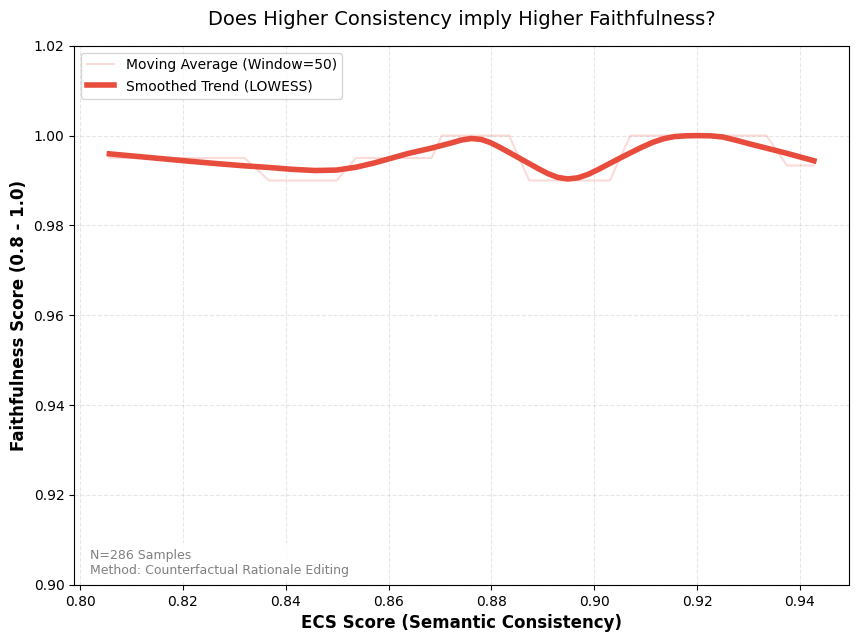

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess
import os

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
# Input Files
FAITHFULNESS_FILE = "gsm8k_cre_faithfulness_scores_mistral.csv"
ECS_FILE          = "gsm8k/gsm8k_mistral7B_ECS.csv" 

# Plot Parameters
WINDOW_SIZE = 50   # Average over 50 examples
STEP_SIZE   = 5    # Slide by 5
SMOOTHING   = 0.3  # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")

# Load Faithfulness Scores
if not os.path.exists(FAITHFULNESS_FILE):
    print(f"❌ Error: Could not find {FAITHFULNESS_FILE}")
    exit()
    
df_scores = pd.read_csv(FAITHFULNESS_FILE, dtype={'id': str})
print(f"   Loaded Faithfulness Scores: {len(df_scores)} rows")

# Load ECS Scores
if not os.path.exists(ECS_FILE):
    print(f"❌ Error: Could not find {ECS_FILE}")
    exit()

df_ecs = pd.read_csv(ECS_FILE, dtype={'id': str})

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if 'ecs' in c.lower()]
if not possible_ecs_cols:
    print("❌ Error: Could not find an 'ECS' column in the ECS file.")
    exit()
ecs_col = possible_ecs_cols[0]

# MERGE
df = pd.merge(df_scores, df_ecs[['id', ecs_col]], on="id", how="inner")

# RENAME COLUMNS
if 'mean_faithfulness' in df.columns:
    df = df.rename(columns={ecs_col: "ECS", "mean_faithfulness": "Faithfulness"})
else:
    print(f"❌ Error: 'mean_faithfulness' column not found.")
    exit()

# Drop rows where Faithfulness is None/NaN
df = df.dropna(subset=["Faithfulness", "ECS"])

# Sort by ECS for the sliding window to work
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW PLOTTER
# -----------------------------
def plot_trend_with_fluctuations(ax, data, x_col, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_x_list = []
    avg_y_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_x_list.append(window[x_col].mean())
        avg_y_list.append(window[y_col].mean())

    if not avg_x_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    ax.plot(avg_x_list, avg_y_list, 
            color=color_hex, 
            alpha=0.2,       # Very transparent
            linewidth=1.5, 
            label="Moving Average (Window=50)")

    # C. Plot the Smoothed Trend (LOWESS)
    x_arr = np.array(avg_x_list)
    y_arr = np.array(avg_y_list)
    
    smooth = lowess(y_arr, x_arr, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,     # Thick line
            label="Smoothed Trend (LOWESS)")

# -----------------------------
# 4. GENERATE THE PLOT
# -----------------------------
print("🎨 Generating Plot...")

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 7))

# Define colors
COLOR = "#e74c3c" # Red/Orange

# Run Plotter
plot_trend_with_fluctuations(
    ax, 
    df, 
    x_col="ECS", 
    y_col="Faithfulness", 
    title="Correlation: Semantic Consistency (ECS) vs. Causal Faithfulness (CRE)",
    color_hex=COLOR
)

# Styling
ax.set_xlabel("ECS Score (Semantic Consistency)", fontsize=12, fontweight='bold')
ax.set_ylabel("Faithfulness Score (0.8 - 1.0)", fontsize=12, fontweight='bold')
ax.set_title("Does Higher Consistency imply Higher Faithfulness?", fontsize=14, pad=15)

# --- Y-Axis Limit (ZOOMED) ---
ax.set_ylim(0.9, 1.02) 
# -----------------------------

# Grid and Legend
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc="upper left", fontsize=10)

# Annotation for interpretation
ax.text(0.02, 0.02, 
        f"N={len(df)} Samples\nMethod: Counterfactual Rationale Editing", 
        transform=ax.transAxes, fontsize=9, color='gray', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Save
filename = "Plot_GSM8K_ECS_vs_CRE_Faithfulness_Zoomed.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"✅ Saved Plot to: {filename}")

plt.show()